## ***Q-1 Solution***

In [25]:
# Importing necessary libraries
import pandas as pd

In [26]:
people_df = pd.read_csv('unique_people_dataset_2000.csv')
teacher_df = pd.read_csv('all_teacher.csv')
print(people_df.head())
print(teacher_df.head())

             name  age  height  weight occupation    location
0   Jeffrey Mason   59   173.0    97.1    Teacher  city_north
1     Gina Deleon   69   149.8    97.2   Mechanic   city_west
2  Victoria Davis   54   171.2    60.0      Pilot   city_west
3   Angela Torres   46   162.7    72.7  Scientist  city_north
4       Tara Pace   58   197.4    51.1    Analyst   city_east
              name  age  height  weight occupation    location  Joining year
0    Jeffrey Mason   59   173.0    97.1    Teacher  city_north          2005
1  Nicholas Rivera   37   147.7    98.4    Teacher   city_east          2005
2   John Armstrong   38   169.0    62.0    Teacher  city_north          2018
3       John Yates   27   160.8    92.8    Teacher   city_west          2001
4     Joseph Colon   42   198.5    54.2    Teacher   city_west          2018


In [27]:
# Parsing the dataset to filter out the required data
for i in range(len(people_df)-1, -1, -1):
    if((people_df.iloc[i]["age"]<30 or people_df.iloc[i]["age"]>45) or (people_df.iloc[i]["height"]<160 or people_df.iloc[i]["height"]>190) or (people_df.iloc[i]["weight"]<50 or people_df.iloc[i]["weight"]>100) or (people_df.iloc[i]["occupation"]!="Teacher") or (people_df.iloc[i]["location"]!="city_south")):
        people_df.drop(people_df.index[i], inplace=True)

people_df.reset_index(drop=True, inplace=True)
print(people_df.head())

            name  age  height  weight occupation    location
0  Jhon Williams   44   169.4    85.9    Teacher  city_south


In [28]:
# Parsing the dataset to filter out the required data
for i in range(len(teacher_df)-1, -1, -1):
    if((teacher_df.iloc[i]["age"]<30 or teacher_df.iloc[i]["age"]>45) or (teacher_df.iloc[i]["height"]<160 or teacher_df.iloc[i]["height"]>190) or (teacher_df.iloc[i]["weight"]<50 or teacher_df.iloc[i]["weight"]>100) or (teacher_df.iloc[i]["occupation"]!="Teacher") or (teacher_df.iloc[i]["location"]!="city_south") or (teacher_df.iloc[i]["Joining year"]>=2014)):
        teacher_df.drop(teacher_df.index[i], inplace=True)

teacher_df.reset_index(drop=True, inplace=True)
print(teacher_df.head())

            name  age  height  weight occupation    location  Joining year
0  Jhon Williams   44   169.4    85.9    Teacher  city_south          2010


## Bonus: Motive of the Killer

Jhon Williams and the victim had been close colleagues for many years and often met secretly at the isolated spot near the pond to talk and drink. Over time, Jhon grew jealous as the victim earned more respect and recognition at school. During one of their meetings, an argument broke out after the victim confronted Jhon regarding certain unethical actions and threatened to reveal the truth. Fearing that his reputation and career would be destroyed, Jhon lost control in a moment of panic and anger. In a fit of rage, he stabbed his closest friend and fled the scene, unknowingly being seen by a witness.

Ironically, the victim's most trusted friend turned out to be his killer.

## ***Q-2 Solution***

In [29]:
# Importing necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [30]:
rocket_df = pd.read_csv('rocket_fuel_data.csv')
print(rocket_df.head())

      Fuel_Type  Temperature_C  Pressure_atm  Thrust_kN  Efficiency_Percent  \
0      HydroX-9         3200.0          85.4     1450.0                88.5   
1  NebulaFuel-3         2800.0           NaN     1200.0                76.2   
2  PlasmaCore-7         4100.0         120.3     2100.0                92.1   
3   CryoBlast-2         1900.0          60.1      850.0                65.4   
4      HydroX-9         3500.0          95.2     1680.0                90.3   

  Reactor_Stability  Oxygen_Level_Percent Target_Planet  
0            Stable                  21.3          Mars  
1          Unstable                  19.8         Venus  
2            Stable                  22.7       Jupiter  
3            Stable                  20.1          Moon  
4            Stable                   NaN          Mars  


In [31]:
# Finding missing values in the dataset
print("missing values in each column:")
print(rocket_df.isnull().sum())

missing values in each column:
Fuel_Type               0
Temperature_C           2
Pressure_atm            5
Thrust_kN               1
Efficiency_Percent      0
Reactor_Stability       0
Oxygen_Level_Percent    3
Target_Planet           0
dtype: int64


In [32]:
# Replace missing values in the dataset
for col in rocket_df.columns:
    if rocket_df[col].dtype!='object':
        if col=="Pressure_atm":
            rocket_df[col].fillna(rocket_df[col].median(), inplace=True)
        else:
            rocket_df[col].fillna(rocket_df[col].mean(), inplace=True)

print("Missing values after replacement:")
print(rocket_df.isnull().sum())

Missing values after replacement:
Fuel_Type               0
Temperature_C           0
Pressure_atm            0
Thrust_kN               0
Efficiency_Percent      0
Reactor_Stability       0
Oxygen_Level_Percent    0
Target_Planet           0
dtype: int64


In [33]:
# Sorting Temperature_C in ascending order
rocket_df = rocket_df.sort_values(by='Temperature_C', ascending=True)
print(rocket_df.head())

      Fuel_Type  Temperature_C  Pressure_atm  Thrust_kN  Efficiency_Percent  \
12  CryoBlast-2         1800.0          58.6      790.0                62.1   
3   CryoBlast-2         1900.0          60.1      850.0                65.4   
37  CryoBlast-2         1950.0          61.0      810.0                63.3   
27  CryoBlast-2         2000.0          63.7      830.0                64.0   
7   CryoBlast-2         2100.0          65.3      920.0                68.2   

   Reactor_Stability  Oxygen_Level_Percent Target_Planet  
12          Unstable                  19.5          Moon  
3             Stable                  20.1          Moon  
37            Stable                  20.0          Moon  
27          Unstable                  19.7          Moon  
7             Stable                  20.5          Moon  


In [34]:
# Sorting Efficiency in descending order
rocket_df = rocket_df.sort_values(by='Efficiency_Percent', ascending=False)
print(rocket_df.head())

       Fuel_Type  Temperature_C  Pressure_atm    Thrust_kN  \
28  PlasmaCore-7         4600.0         140.2  2700.000000   
13  PlasmaCore-7         4500.0         135.7  2600.000000   
23  PlasmaCore-7         4400.0         132.5  2500.000000   
38  PlasmaCore-7         4350.0         130.1  1558.717949   
18  PlasmaCore-7         4200.0         128.4  2420.000000   

    Efficiency_Percent Reactor_Stability  Oxygen_Level_Percent Target_Planet  
28                97.0            Stable                  25.5       Jupiter  
13                96.3            Stable                  25.1       Jupiter  
23                95.8            Stable                  24.8       Jupiter  
38                95.5            Stable                  24.6       Jupiter  
18                95.1            Stable                  24.5          Mars  


In [35]:
# Creating new column for power index
rocket_df['Power_Index'] = rocket_df['Thrust_kN'] * rocket_df['Efficiency_Percent']
print(rocket_df.head())

       Fuel_Type  Temperature_C  Pressure_atm    Thrust_kN  \
28  PlasmaCore-7         4600.0         140.2  2700.000000   
13  PlasmaCore-7         4500.0         135.7  2600.000000   
23  PlasmaCore-7         4400.0         132.5  2500.000000   
38  PlasmaCore-7         4350.0         130.1  1558.717949   
18  PlasmaCore-7         4200.0         128.4  2420.000000   

    Efficiency_Percent Reactor_Stability  Oxygen_Level_Percent Target_Planet  \
28                97.0            Stable                  25.5       Jupiter   
13                96.3            Stable                  25.1       Jupiter   
23                95.8            Stable                  24.8       Jupiter   
38                95.5            Stable                  24.6       Jupiter   
18                95.1            Stable                  24.5          Mars   

      Power_Index  
28  261900.000000  
13  250380.000000  
23  239500.000000  
38  148857.564103  
18  230142.000000  


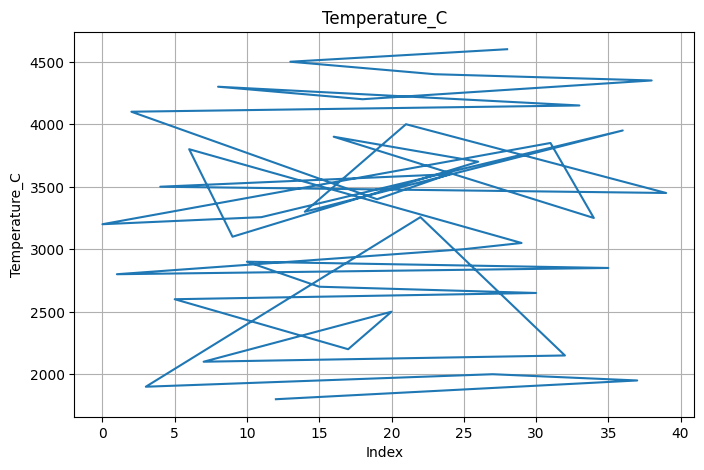

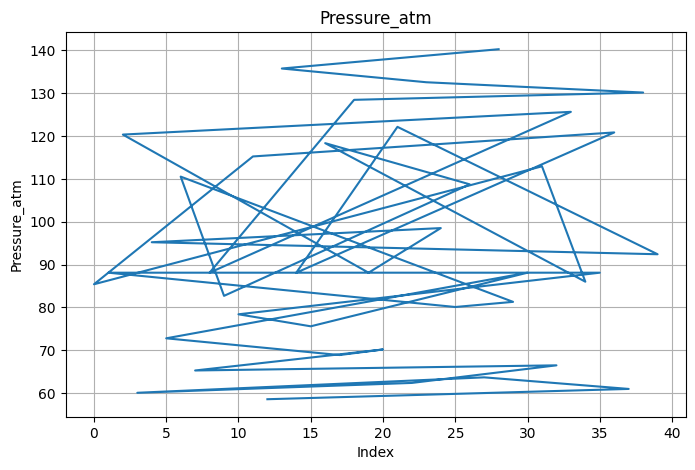

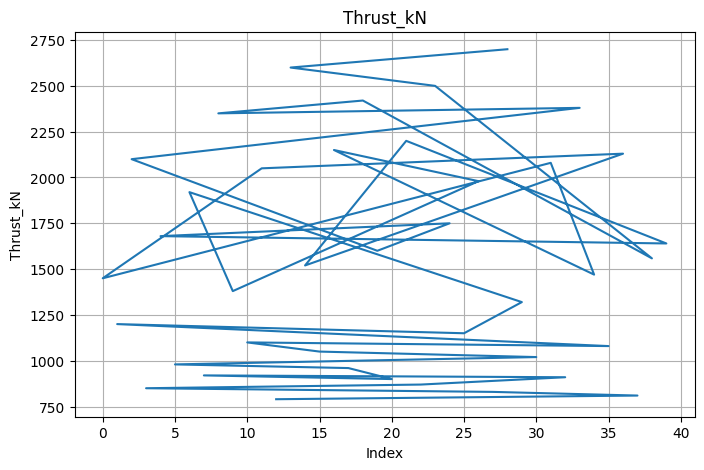

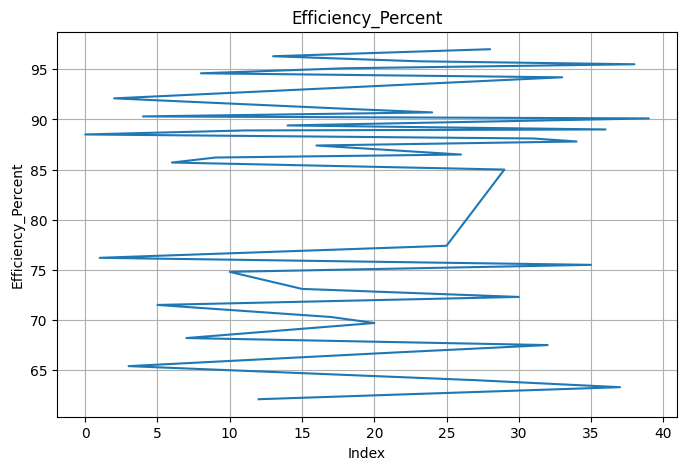

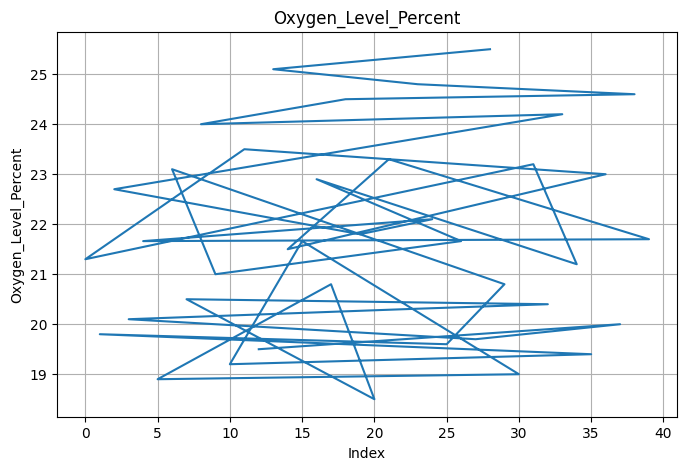

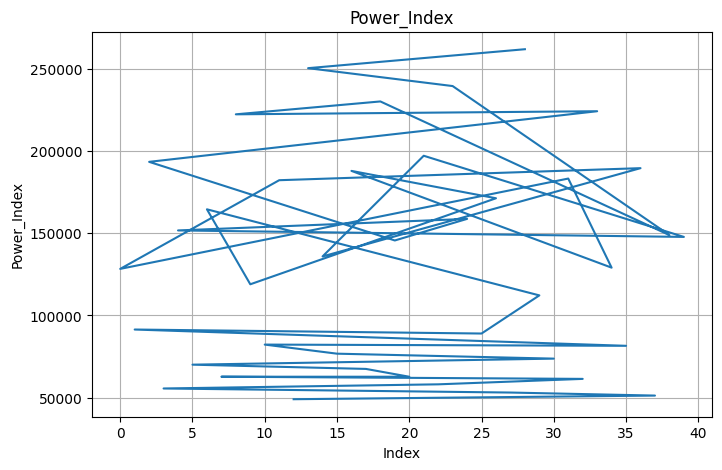

In [36]:
# Plotting all numerical columns in the dataset
numerical=rocket_df.select_dtypes(include=np.number)
for col in numerical.columns:
    plt.figure(figsize=(8,5))
    plt.plot(rocket_df[col])
    plt.title(col)
    plt.xlabel("Index")
    plt.ylabel(col)
    plt.grid()
    plt.show()

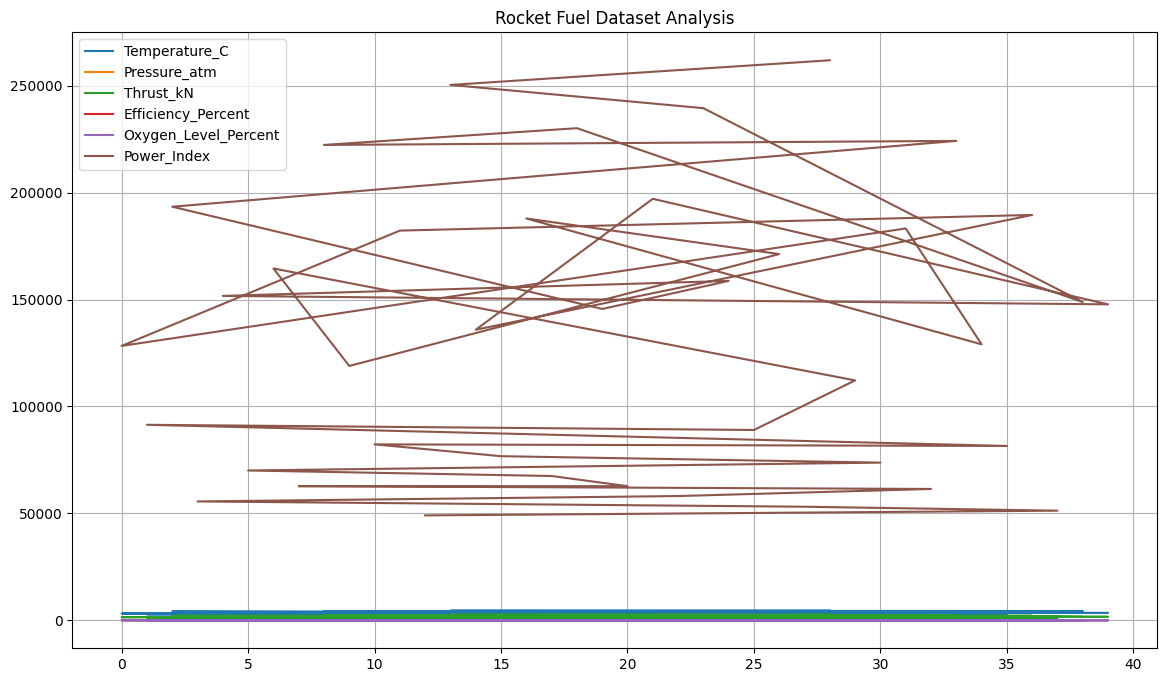

In [37]:
# Alternative Combined graph
numerical.plot(figsize=(14,8))
plt.title("Rocket Fuel Dataset Analysis")
plt.grid()
plt.show()

In [38]:
# Saving the modified dataset to a new CSV file
rocket_df.to_csv("modified.csv", index=False)
print("Modified file saved successfully")

Modified file saved successfully


In [39]:
new_df = pd.read_csv("modified.csv")
print(new_df.head())

      Fuel_Type  Temperature_C  Pressure_atm    Thrust_kN  Efficiency_Percent  \
0  PlasmaCore-7         4600.0         140.2  2700.000000                97.0   
1  PlasmaCore-7         4500.0         135.7  2600.000000                96.3   
2  PlasmaCore-7         4400.0         132.5  2500.000000                95.8   
3  PlasmaCore-7         4350.0         130.1  1558.717949                95.5   
4  PlasmaCore-7         4200.0         128.4  2420.000000                95.1   

  Reactor_Stability  Oxygen_Level_Percent Target_Planet    Power_Index  
0            Stable                  25.5       Jupiter  261900.000000  
1            Stable                  25.1       Jupiter  250380.000000  
2            Stable                  24.8       Jupiter  239500.000000  
3            Stable                  24.6       Jupiter  148857.564103  
4            Stable                  24.5          Mars  230142.000000  
